Title: Bias_analysis_plot.ipynb

Purpose: Make a plot comparing the preprocessed climate variables and their mean over the masked area

Author: Onno Nennecke on 23.05.2025 Modified: 23.05.2025

Input data: 

- Preprocessed climate data
    - These files lie here: /climca/people/onennecke/not_debiased_data/
- Mask data
    - These files lie here: /climca/people/onennecke/Wind_Solar_MaStR/processed_data/
- Table of used runs
    - This file lies here: /home/onennecke/CMIP_models/CMIP6_runs.csv

Output data:

- Bias_analysis_plot
    - This file lies here: /home/onennecke/Code/Figures/Bias_analysis_plot.png 

### Load libraries and functions

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os
import glob
import time

from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

----

In [2]:
# Load installed capacity data
grid_offshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic.nc')
grid_offshore = grid_offshore['wind_off_cap']
mask_offshore = xr.where(np.isfinite(grid_offshore), 1, 0)
grid_onshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic.nc')
grid_onshore = grid_onshore['wind_on_cap']
mask_onshore = xr.where(np.isfinite(grid_onshore), 1, 0)
grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic.nc')
grid_solar = grid_solar['solar_cap']
mask_solar = xr.where(np.isfinite(grid_solar), 1, 0)
population = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')
population = population['population']
mask_population = xr.where(np.isfinite(population), 1, 0)

# Overall mask
overall_mask = mask_offshore + mask_onshore + mask_solar + mask_population
overall_mask = xr.where(overall_mask > 0, 1, 0)

In [3]:
# Read the dataframe from the csv file
used_runs = pd.read_csv('/home/onennecke/CMIP_models/CMIP6_runs.csv')


# Add one row with ERA5 using pd.concat
era5_row = pd.DataFrame([{
    'ESM': 'ERA5',
    'Institution': 'ECMWF',
    'run': 'hist'
}])
used_runs = pd.concat([used_runs, era5_row], ignore_index=True)

# Change the ref column to 1 for the first instance of each model
used_runs['Ref'] = used_runs.groupby(['ESM', 'Institution']).cumcount().apply(lambda x: 1 if x == 0 else 0)

used_runs

,ESM,Institution,run,Ref
0,ACCESS-CM2,CSIRO-ARCCSS,r4i1p1f1,1
1,ACCESS-CM2,CSIRO-ARCCSS,r5i1p1f1,0
2,ACCESS-CM2,CSIRO-ARCCSS,r1i1p1f1,0
3,BCC-CSM2-MR,BCC,r1i1p1f1,1
4,CESM2,NCAR,r4i1p1f1,1
...,...,...,...,...
95,UKESM1-0-LL,MOHC,r8i1p1f2,0
96,UKESM1-0-LL,NIMS-KMA,r15i1p1f2,1
97,UKESM1-0-LL,NIMS-KMA,r13i1p1f2,0
98,UKESM1-0-LL,NIMS-KMA,r14i1p1f2,0


In [4]:
# Count runs per model
model_counts = used_runs.groupby('ESM').size().reset_index(name='count')
model_counts

,ESM,count
0,ACCESS-CM2,3
1,BCC-CSM2-MR,1
2,CESM2,3
3,EC-Earth3,53
4,ERA5,1
5,GFDL-ESM4,1
6,KACE-1-0-G,3
7,MPI-ESM1-2-HR,10
8,MRI-ESM2-0,5
9,TaiESM1,1


In [14]:
for i in range(len(used_runs)):
    run_time = time.time()
    ESM = used_runs['ESM'][i]
    Inst = used_runs['Institution'][i]
    run = used_runs['run'][i]
    print(f'Processing Run Nr. {i+1}, {ESM}, {Inst}, {run}, \n')
    # base_path = '/climca/people/onennecke/debiased_data/'
    base_path = '/climca/people/onennecke/not_debiased_data/'

    sel_run = glob.glob(os.path.join(base_path, f"{ESM}_{run}_*"))

    # now drop any psl files
    sel_run = [fn for fn in sel_run if '_psl' not in os.path.basename(fn)]
    # print(sel_run)
    combined_ds = xr.open_mfdataset(sel_run)
    combined_ds = combined_ds.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')
    # Add DOY coordinate
    combined_ds['time'] = pd.to_datetime(combined_ds['time'].values)
    # combined_ds = combined_ds.assign_coords(DOY=combined_ds['time'].dt.dayofyear)
    
    timeseries_ds = xr.Dataset()
    timeseries_ds['rsds_masked'] = combined_ds['rsds'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
    timeseries_ds['sfcWind_masked'] = combined_ds['sfcWind'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
    timeseries_ds['tas_masked'] = combined_ds['tas'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
    timeseries_ds['tasmax_masked'] = combined_ds['tasmax'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
    timeseries_ds.load()
    timeseries_ds.to_netcdf(f'/climca/people/onennecke/model_output/var_means_masked/full_year/{ESM}_{run}_timeseries.nc', mode='w')
    # break


Processing Run Nr. 1, ACCESS-CM2, CSIRO-ARCCSS, r4i1p1f1, 

Processing Run Nr. 2, ACCESS-CM2, CSIRO-ARCCSS, r5i1p1f1, 

Processing Run Nr. 3, ACCESS-CM2, CSIRO-ARCCSS, r1i1p1f1, 

Processing Run Nr. 4, BCC-CSM2-MR, BCC, r1i1p1f1, 

Processing Run Nr. 5, CESM2, NCAR, r4i1p1f1, 

Processing Run Nr. 6, CESM2, NCAR, r10i1p1f1, 

Processing Run Nr. 7, CESM2, NCAR, r11i1p1f1, 

Processing Run Nr. 8, EC-Earth3, EC-Earth-Consortium, r149i1p1f1, 

Processing Run Nr. 9, EC-Earth3, EC-Earth-Consortium, r4i1p1f1, 

Processing Run Nr. 10, EC-Earth3, EC-Earth-Consortium, r148i1p1f1, 

Processing Run Nr. 11, EC-Earth3, EC-Earth-Consortium, r105i1p1f1, 

Processing Run Nr. 12, EC-Earth3, EC-Earth-Consortium, r134i1p1f1, 

Processing Run Nr. 13, EC-Earth3, EC-Earth-Consortium, r141i1p1f1, 

Processing Run Nr. 14, EC-Earth3, EC-Earth-Consortium, r146i1p1f1, 

Processing Run Nr. 15, EC-Earth3, EC-Earth-Consortium, r112i1p1f1, 

Processing Run Nr. 16, EC-Earth3, EC-Earth-Consortium, r117i1p1f1, 

Processi

In [5]:
path = '/climca/people/onennecke/model_output/var_means_masked/full_year/'

files = sorted(glob.glob(os.path.join(path, '*.nc')))
# files = files[:60] + files[61:]
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')
# files

# Rename variables without _masked
ts_datasets = ts_datasets.rename({
    'sfcWind_masked': 'sfcWind',
    'rsds_masked': 'rsds',
    'tas_masked': 'tas',
    'tasmax_masked': 'tasmax'
})

# Add day of year as a coordinate
# ts_datasets = ts_datasets.assign_coords(doy=np.tile(np.arange(1, 366), 10))
ts_datasets.coords['doy'] = (('time',), np.tile(np.arange(1, 366), 10))

ts_datasets.load()

<xarray.Dataset> Size: 7MB
Dimensions:   (ESM_run: 100, time: 3650)
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * time      (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       (ESM_run) <U13 5kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run       (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2' 'r9i1p1f2'
  * ESM_run   (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r9i1p...
    country   float64 8B 9.0
    doy       (time) int64 29kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365
Data variables:
    rsds      (ESM_run, time) float32 1MB 13.75 24.11 38.15 ... 19.2 17.57 21.48
    sfcWind   (ESM_run, time) float64 3MB 8.056 6.177 6.451 ... 10.63 9.856
    tas       (ESM_run, time) float32 1MB 275.3 272.4 270.5 ... 279.4 277.5
    tasmax    (ESM_run, time) float32 1MB 277.2 273.9 272.2 ... 280.8 278.5

----

### Calculate Model Bias

In [6]:
# Group data by ESMs and calculate mean temp, demand, wind, ...
all_dfs = []
for esm in np.unique(ts_datasets['ESM'].values):
    filtered_dataset = ts_datasets.where(ts_datasets['ESM'] == esm, drop=True)
    mean_by_day = filtered_dataset.groupby('doy').mean(dim=['time', 'ESM_run'])
    df = pd.DataFrame({
        'doy': mean_by_day['doy'].values,
        #### 'temp': mean_by_day['temp'].values,
        #### 'demand': mean_by_day['demand'].values,
        #### 'demand_weekly': mean_by_day['demand_weekly'].values,
        'sfcWind': mean_by_day['sfcWind'].values,
        'rsds' : mean_by_day['rsds'].values,
        'tas': mean_by_day['tas'].values,
        'tasmax': mean_by_day['tasmax'].values,
        #### 'wind_off_prod': mean_by_day['wind_off_prod'].values,
        #### 'wind_on_prod': mean_by_day['wind_on_prod'].values,
        #### 'solar_prod': mean_by_day['solar_prod'].values,
        #### 'total_prod': mean_by_day['total_prod'].values,
        #### 'netto': mean_by_day['Netto'].values,
        #### 'Residual_load': mean_by_day['Residual_load'].values,
    })
    df['ESM'] = esm
    all_dfs.append(df)

final_df = pd.concat(all_dfs, ignore_index=True)

final_df

,doy,sfcWind,rsds,tas,tasmax,ESM
0,1,6.832429,23.096914,274.830353,276.532104,ACCESS-CM2
1,2,6.756827,23.791636,274.682465,276.377991,ACCESS-CM2
2,3,6.731797,26.174891,274.051300,275.734375,ACCESS-CM2
3,4,6.608799,27.544230,273.658417,275.408020,ACCESS-CM2
4,5,6.510941,28.201057,273.170929,274.980011,ACCESS-CM2
...,...,...,...,...,...,...
4010,361,5.974821,26.066833,273.956482,275.977997,UKESM1-0-LL
4011,362,6.066361,27.131372,273.843231,275.899292,UKESM1-0-LL
4012,363,6.123416,26.580833,273.823853,275.899231,UKESM1-0-LL
4013,364,6.049092,26.170652,273.884979,275.871338,UKESM1-0-LL


In [7]:
# For Boxplots per model
df = ts_datasets.to_dataframe().reset_index()

variables = [
    'sfcWind', 'rsds', 'tas', 'tasmax' # , 'temp', 'demand', 'demand_weekly', 'wind_off_prod', 'wind_on_prod', 'solar_prod', 'total_prod', 'Residual_load'
]


# Compute ESM counts once and create labels
esm_counts = (df['ESM'].value_counts().sort_index() // 1820).astype(int)
esm_label_map = {esm: f"{esm} (n={count})" for esm, count in esm_counts.items()}
df['ESM_label'] = df['ESM'].map(esm_label_map)

In [8]:
all_dfs = []
for var in variables:
    ERA5_mean = ts_datasets[var].sel(ESM_run='ERA5_hist').mean('time')
    model_mean = ts_datasets[var].groupby('ESM').mean().mean('time')
    # overall_mean = ts_datasets[var].mean('time').mean()
    
    overall_mean = ts_datasets[var].mean('time').mean('ESM_run')
    
    bias = model_mean - ERA5_mean
    
    df_bias = pd.DataFrame({
        'ESM': np.unique(ts_datasets['ESM'].values),
        # 'ERA5_mean': ERA5_mean.values,
        f'model_mean_{var}': model_mean.values,
        f'overall_mean_{var}': overall_mean.values,
        f'bias_{var}': bias.values
    })
    all_dfs.append(df_bias)
final_df_bias = pd.concat(all_dfs, axis=1, ignore_index=False)
final_df_bias = final_df_bias.loc[:,~final_df_bias.columns.duplicated()]


In [ ]:
# Save the DataFrame to a CSV file
# final_df_bias.to_csv('/climca/people/onennecke/model_output/var_means/biases.csv', index=False)
final_df_bias.to_csv('/climca/people/onennecke/model_output/var_means_masked/biases_all_year.csv', index=False)

In [6]:
final_df_bias

,ESM,model_mean_sfcWind,overall_mean_sfcWind,bias_sfcWind,model_mean_rsds,overall_mean_rsds,bias_rsds,model_mean_tas,overall_mean_tas,bias_tas,model_mean_tasmax,overall_mean_tasmax,bias_tasmax
0,ACCESS-CM2,4.883765,5.660072,-0.607462,133.966736,134.284134,2.592621,281.791534,282.396179,-1.489899,284.509857,285.552002,-2.159241
1,BCC-CSM2-MR,6.007326,5.660072,0.516099,123.834312,134.284134,-7.539803,282.220337,282.396179,-1.061096,285.514465,285.552002,-1.154633
2,CESM2,5.956903,5.660072,0.465676,134.456543,134.284134,3.082428,284.068146,282.396179,0.786713,287.175415,285.552002,0.506317
3,EC-Earth3,5.933132,5.660072,0.441905,132.116699,134.284134,0.742584,282.232544,282.396179,-1.048889,285.493866,285.552002,-1.175232
4,ERA5,5.491227,5.660072,0.000000,131.374115,134.284134,0.000000,283.281433,282.396179,0.000000,286.669098,285.552002,0.000000
5,GFDL-ESM4,5.926543,5.660072,0.435317,127.846817,134.284134,-3.527298,281.833099,282.396179,-1.448334,284.404327,285.552002,-2.264771
6,KACE-1-0-G,6.664248,5.660072,1.173021,147.618362,134.284134,16.244247,283.146301,282.396179,-0.135132,286.773315,285.552002,0.104218
7,MPI-ESM1-2-HR,5.271056,5.660072,-0.220170,125.393410,134.284134,-5.980705,282.029541,282.396179,-1.251892,284.759125,285.552002,-1.909973
8,MRI-ESM2-0,5.013921,5.660072,-0.477306,143.415115,134.284134,12.041000,283.669250,282.396179,0.387817,286.371979,285.552002,-0.297119
9,TaiESM1,4.621355,5.660072,-0.869871,138.335449,134.284134,6.961334,284.293060,282.396179,1.011627,288.393677,285.552002,1.724579


In [9]:
df

,ESM_run,time,rsds,sfcWind,tas,tasmax,crs,gridtype,ESM,run,country,doy,ESM_label
0,ACCESS-CM2_r1i1p1f1,2015-01-01,13.747292,8.056400,275.264221,277.182495,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,1,ACCESS-CM2 (n=6)
1,ACCESS-CM2_r1i1p1f1,2015-01-02,24.114571,6.177364,272.357574,273.902313,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,2,ACCESS-CM2 (n=6)
2,ACCESS-CM2_r1i1p1f1,2015-01-03,38.148254,6.450903,270.521271,272.201721,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,3,ACCESS-CM2 (n=6)
3,ACCESS-CM2_r1i1p1f1,2015-01-04,31.047712,6.054282,271.283936,274.638580,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,4,ACCESS-CM2 (n=6)
4,ACCESS-CM2_r1i1p1f1,2015-01-05,21.248137,4.147174,273.937195,274.950043,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,5,ACCESS-CM2 (n=6)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
364995,UKESM1-0-LL_r9i1p1f2,2024-12-27,15.382012,13.253636,279.751495,281.625305,4326,lonlat,UKESM1-0-LL,r9i1p1f2,9.0,361,UKESM1-0-LL (n=38)
364996,UKESM1-0-LL_r9i1p1f2,2024-12-28,12.113527,13.579572,278.034515,278.795258,4326,lonlat,UKESM1-0-LL,r9i1p1f2,9.0,362,UKESM1-0-LL (n=38)
364997,UKESM1-0-LL_r9i1p1f2,2024-12-29,19.195608,7.520935,277.587555,279.348694,4326,lonlat,UKESM1-0-LL,r9i1p1f2,9.0,363,UKESM1-0-LL (n=38)
364998,UKESM1-0-LL_r9i1p1f2,2024-12-30,17.566565,10.625086,279.358521,280.813690,4326,lonlat,UKESM1-0-LL,r9i1p1f2,9.0,364,UKESM1-0-LL (n=38)


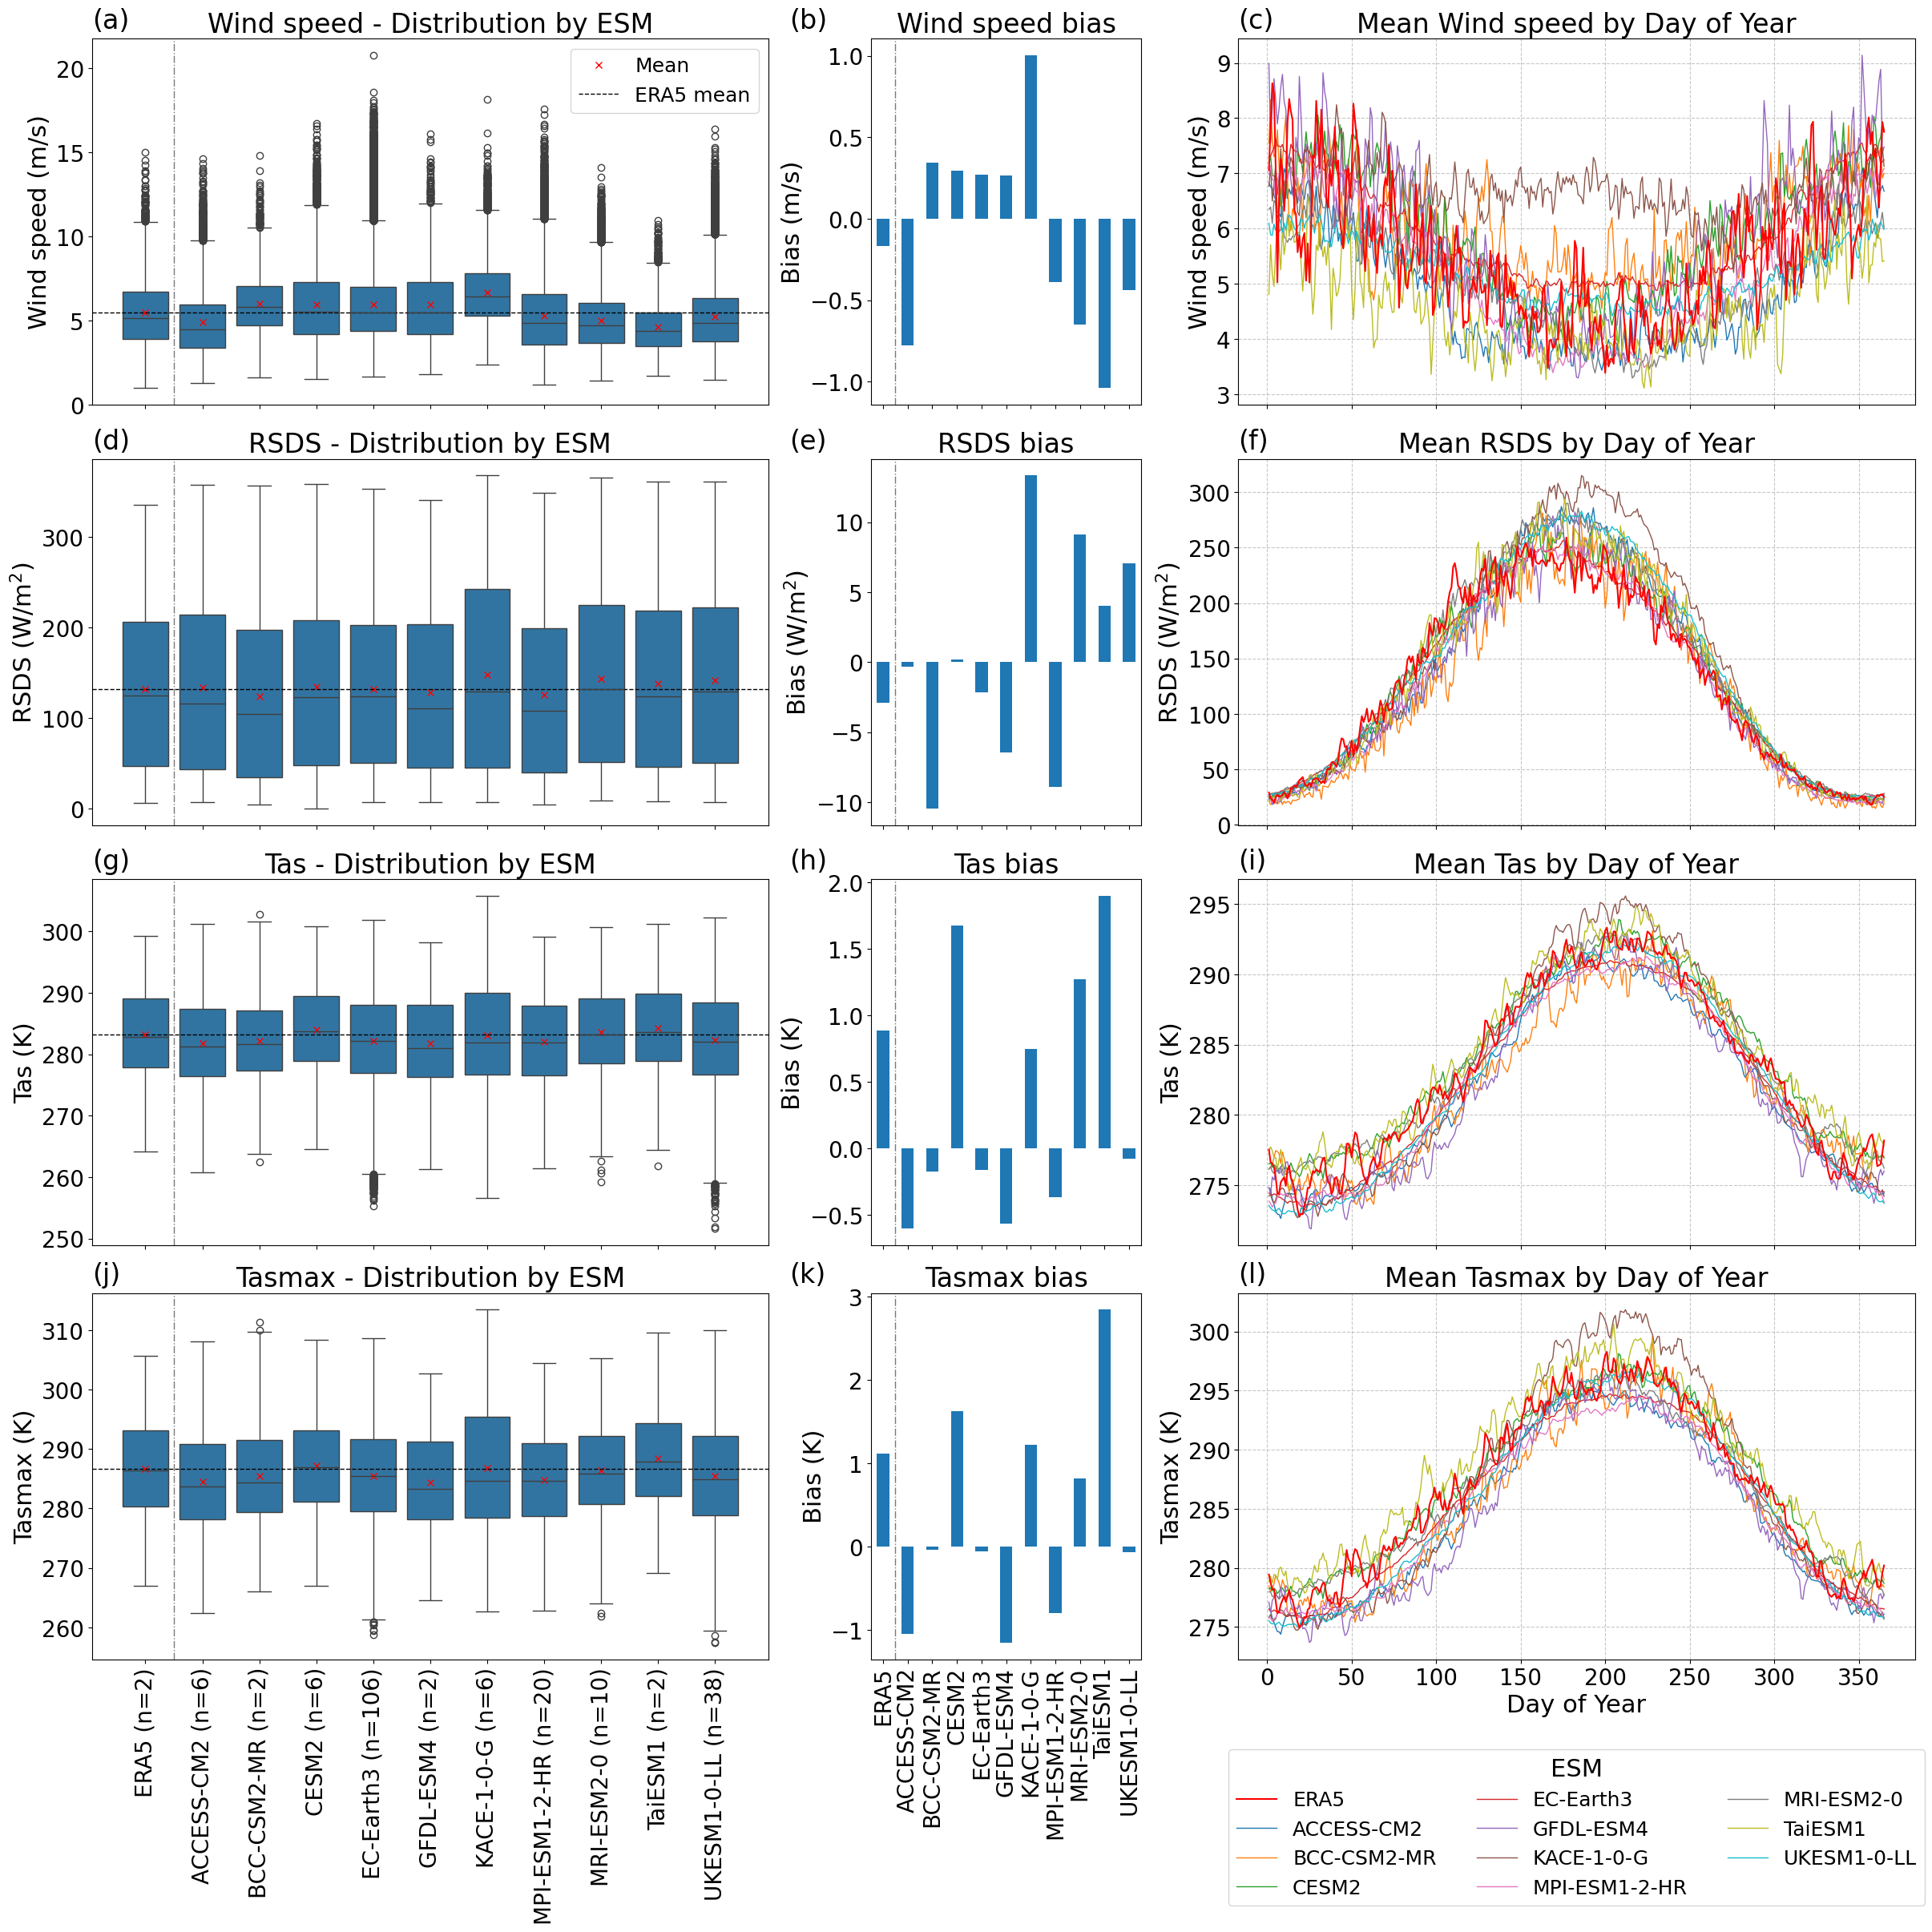

In [ ]:
mpl.rcParams.update({
    'font.size': 22,
    'axes.titlesize': 24,
    'axes.labelsize': 22,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 18,
    'figure.titlesize': 24,
})


# example units mapping — edit keys to match your variable names
units = {
    'sfcWind': 'm/s',
    'rsds': r'W/m$^2$',
    'tas': 'K',
    'tasmax': 'K'
    # add more variable: unit pairs as needed
}

n_vars = len(variables)
fig, axes = plt.subplots(
    n_vars, 3,
    figsize=(24, 6 * n_vars),
    gridspec_kw={'width_ratios': [3, 1.2, 3]},
    constrained_layout=True,
    sharex='col'
)

# Make sure axes is 2D even when n_vars == 1
if n_vars == 1:
    axes = np.expand_dims(axes, axis=0)

for i, var in enumerate(variables):
    if var == 'sfcWind':
        display_var = 'Wind speed'
    elif var == 'tas':
        display_var = 'Tas'
    elif var == 'tasmax':
        display_var = 'Tasmax'
    else:
        display_var = 'RSDS'
    ax_box = axes[i, 0]
    ax_bias = axes[i, 1]
    ax_line = axes[i, 2]

    # --- BOXPLOT (left) ---
    # Determine order so ERA5 (or any label containing 'ERA5') is first
    labels = list(df['ESM_label'].unique())
    era5_candidates = [lab for lab in labels if 'ERA5' in str(lab)]
    if era5_candidates:
        era5_label = era5_candidates[0]
        order = [era5_label] + [lab for lab in labels if lab != era5_label]
    else:
        order = labels  # fallback if no ERA5 label present

    sns.boxplot(data=df, x='ESM_label', y=var, order=order, ax=ax_box)
    # plot means at the categorical x positions
    means = df.groupby('ESM_label')[var].mean().reindex(order)
    x_positions = np.arange(len(order))
    ax_box.plot(x_positions, means.values, color='red', marker='x', linestyle='', label='Mean')

    # dashed vertical line that separates ERA5 (at position 0) from the rest
    if len(order) > 1:
        ax_box.axvline(x=0.5, color="#7A7878", linestyle='-.', linewidth=1)

    # ERA5_hist mean horizontal (if ts_datasets contains it)
    era5_hist_val = ts_datasets[var].sel(ESM_run='ERA5_hist').mean('time')
    ax_box.axhline(y=float(era5_hist_val), color='black', linestyle='--', linewidth=1, label='ERA5 mean')

    ax_box.set_title(f'{display_var} - Distribution by ESM')
    ax_box.tick_params(axis='x', rotation=90)
    ax_box.set_xlabel('')
    ax_box.set_ylabel(f'{display_var} ({units[var]})')
    # optional: show legend for mean / ERA5_hist in the boxplot
    if i == 0:
        ax_box.legend(loc='upper right')

    # --- BIAS BARPLOT (middle) ---
    model_mean = ts_datasets[var].groupby('ESM').mean().mean('time')
    overall_mean = ts_datasets[var].mean('time').mean()
    bias = model_mean - overall_mean

    # ensure ERA5 (or any index containing 'ERA5') comes first in the barplot
    bias_series = bias.to_series()
    era5_idx = next((idx for idx in bias_series.index if 'ERA5' in str(idx)), None)
    if era5_idx is not None:
        ordered_idx = [era5_idx] + [idx for idx in bias_series.index if idx != era5_idx]
    else:
        ordered_idx = list(bias_series.index)

    bias_ordered = bias_series.reindex(ordered_idx)

    # plot with explicit x positions so we can place the separator exactly between first and second bars
    x = np.arange(len(ordered_idx))
    ax_bias.bar(x, bias_ordered.values, width=0.5)
    ax_bias.set_xticks(x)
    ax_bias.set_xticklabels(ordered_idx, rotation=90)

    # set x-limits so vertical separator falls between first and second bar
    ax_bias.set_xlim(-0.5, len(ordered_idx) - 0.5)

    # dashed vertical separator (same style as boxplot)
    if len(ordered_idx) > 1:
        ax_bias.axvline(x=0.5, color="#7A7878", linestyle='-.', linewidth=1)

    ax_bias.set_title(f'{display_var} bias')
    ax_bias.set_ylabel(f'Bias ({units[var]})')
    ax_bias.set_xlabel('')
    ax_bias.tick_params(axis='x', rotation=90)


    # --- LINE PLOT (right) ---
    if var in final_df.columns:
        # ensure ERA5 is plotted first (if present)
        unique_esms = list(final_df['ESM'].unique())
        ordered_esms = []
        if 'ERA5' in unique_esms:
            ordered_esms.append('ERA5')
        ordered_esms += [e for e in unique_esms if e not in ordered_esms]

        for esm in ordered_esms:
            group = final_df[final_df['ESM'] == esm]
            if group.empty:
                continue
            if esm == 'ERA5':
                ax_line.plot(group['doy'], group[var], color='red', linewidth=1.5, label='ERA5', zorder=10)
            else:
                ax_line.plot(group['doy'], group[var], linewidth=1, label=esm)

        ax_line.set_title(f'Mean {display_var} by Day of Year')
        if i == n_vars - 1:
            ax_line.set_xlabel('Day of Year')
        # put units (if known) into the y-axis label
        unit = units.get(var, '')
        ax_line.set_ylabel(f'{display_var} ({units[var]})')


        ax_line.grid(True, linestyle='--', alpha=0.7)

        # Ensure legend starts with ERA5 if present
        handles, labels_ = ax_line.get_legend_handles_labels()
        if 'ERA5' in labels_:
            idx = labels_.index('ERA5')
            # reorder handles/labels so ERA5 is first
            handles = [handles[idx]] + [h for j, h in enumerate(handles) if j != idx]
            labels_ = ['ERA5'] + [l for j, l in enumerate(labels_) if j != idx]

        # ax_line.legend(handles, labels_, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title='ESM')
        # if i == 0:
        if i == n_vars - 1:
            ax_line.legend(handles, labels_, bbox_to_anchor=(0.5, -0.7), loc='lower center', ncol=3, fontsize=18, title='ESM')

# --- per-column / per-row adjustable subplot letter labels (a)-(...) ---
# Configure these to control label positions:
start_letter = 'a'          # first letter for labeling: 'a' -> (a), etc.
label_fontsize = 24
ha_per_col = None           # None (defaults to 'left') or list of length n_cols with 'left'/'center'/'right'
va_per_row = None           # None (defaults to 'top') or list of length n_rows with 'top'/'center'/'bottom'

# Provide x offsets per column and y offsets per row (in axis fraction coordinates 0..1).
# You can give a single float (broadcast) or a sequence matching number of columns/rows.
x_offsets_per_col = [0, -0.3, 0]    # or e.g. [0.01, 0.02, 0.04] for 3 columns
y_offsets_per_row = [1.085, 1.085, 1.085, 1.085]    # or e.g. [0.95, 0.92, 0.95] for 3 rows

# --- end of user configuration ---

n_rows, n_cols = axes.shape
n_axes_total = n_rows * n_cols

# Create labels (a), (b), ... up to the number of axes
labels = [f'({chr(ord(start_letter) + i)})' for i in range(n_axes_total)]

# Normalize x_offsets_per_col -> list of length n_cols
if isinstance(x_offsets_per_col, (int, float)):
    x_offsets = [float(x_offsets_per_col)] * n_cols
else:
    x_offsets = list(x_offsets_per_col)
    if len(x_offsets) != n_cols:
        raise ValueError(f"x_offsets_per_col must be a float or list of length {n_cols} (num cols).")

# Normalize y_offsets_per_row -> list of length n_rows
if isinstance(y_offsets_per_row, (int, float)):
    y_offsets = [float(y_offsets_per_row)] * n_rows
else:
    y_offsets = list(y_offsets_per_row)
    if len(y_offsets) != n_rows:
        raise ValueError(f"y_offsets_per_row must be a float or list of length {n_rows} (num rows).")

# Normalize horizontal/vertical alignment defaults or lists
if ha_per_col is None:
    ha_list = ['left'] * n_cols
elif isinstance(ha_per_col, str):
    ha_list = [ha_per_col] * n_cols
else:
    ha_list = list(ha_per_col)
    if len(ha_list) != n_cols:
        raise ValueError(f"ha_per_col must be None, a str, or list of length {n_cols} (num cols).")

if va_per_row is None:
    va_list = ['top'] * n_rows
elif isinstance(va_per_row, str):
    va_list = [va_per_row] * n_rows
else:
    va_list = list(va_per_row)
    if len(va_list) != n_rows:
        raise ValueError(f"va_per_row must be None, a str, or list of length {n_rows} (num rows).")

# Place labels: use row-major ordering for label assignment (same as axes.flatten())
lab_idx = 0
for r in range(n_rows):
    for c in range(n_cols):
        if lab_idx >= len(labels):
            break
        ax = axes[r, c]
        x_off = x_offsets[c]
        y_off = y_offsets[r]
        ha = ha_list[c]
        va = va_list[r]
        ax.text(
            x_off, y_off, labels[lab_idx],
            transform=ax.transAxes,
            fontsize=label_fontsize,
            ha=ha, va=va
        )
        lab_idx += 1
# --- end adjustable labels ---


# overall title
# fig.suptitle('Variables — Distribution, Bias, and Seasonal Evolution', fontsize=16)
# Save the figure
# plt.savefig('/home/onennecke/Code/Figures/Bias_analysis_plot.png', bbox_inches='tight', dpi=300)

plt.show()


# Old version

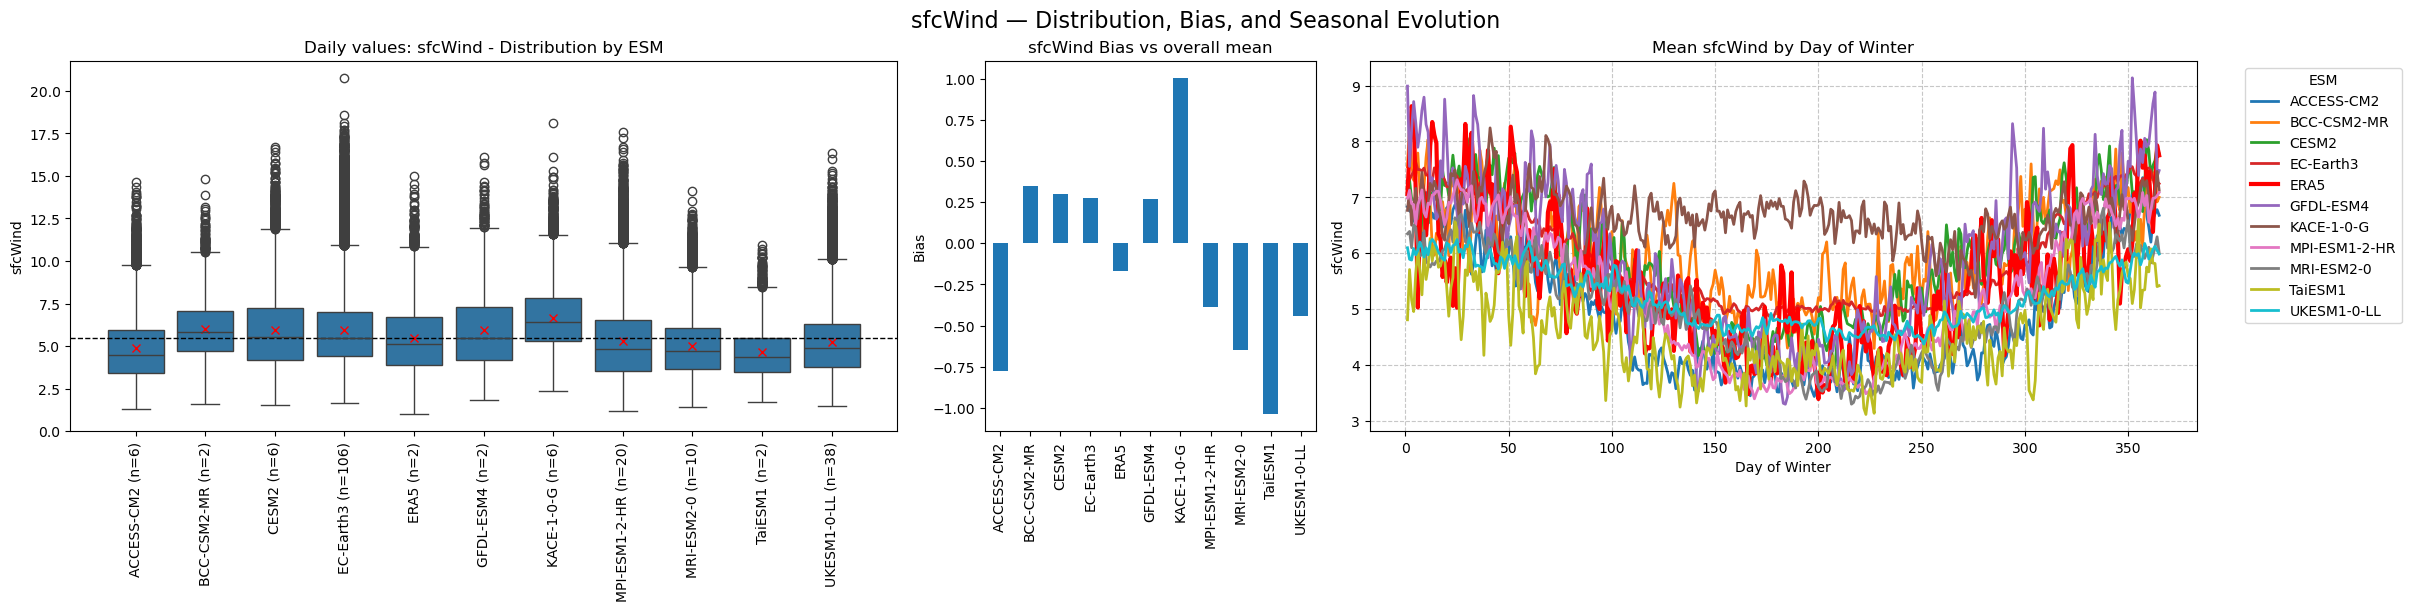

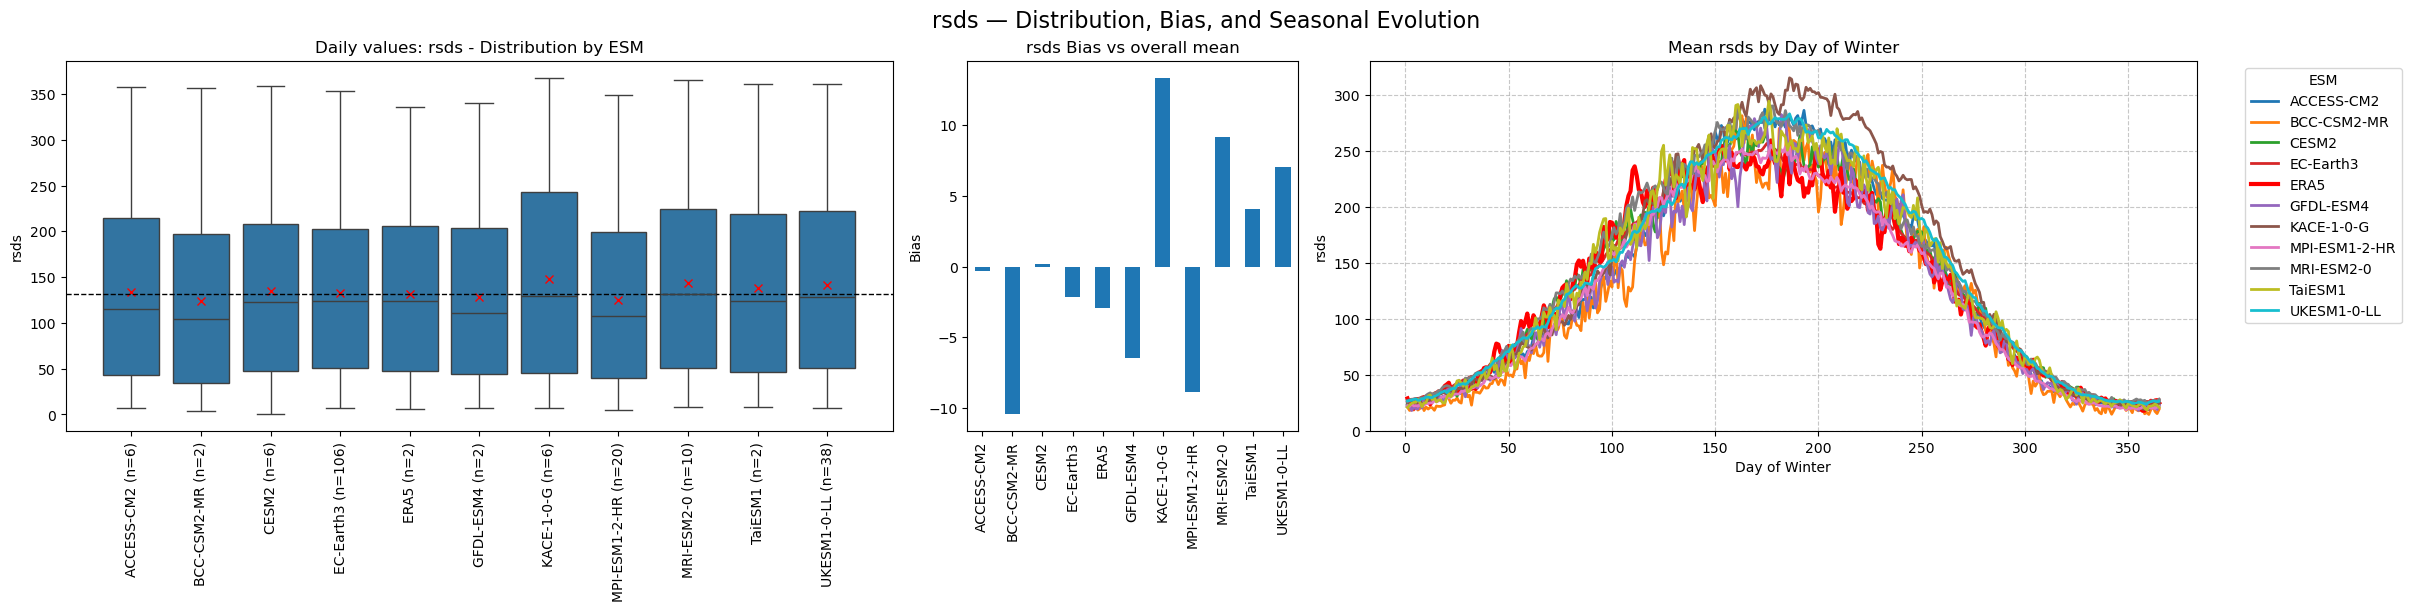

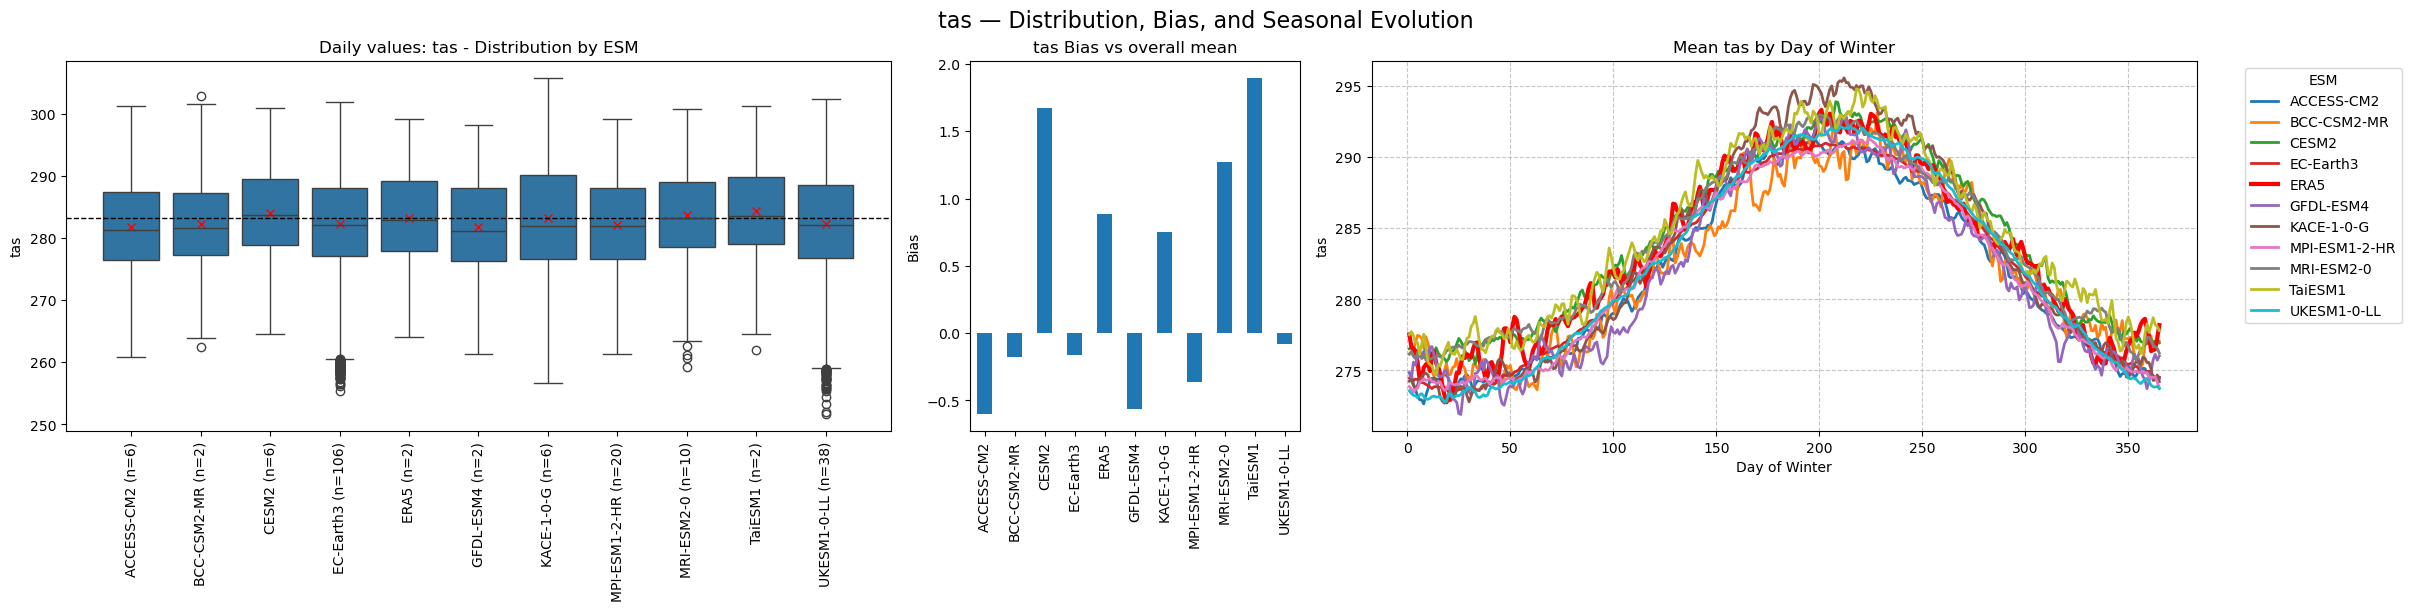

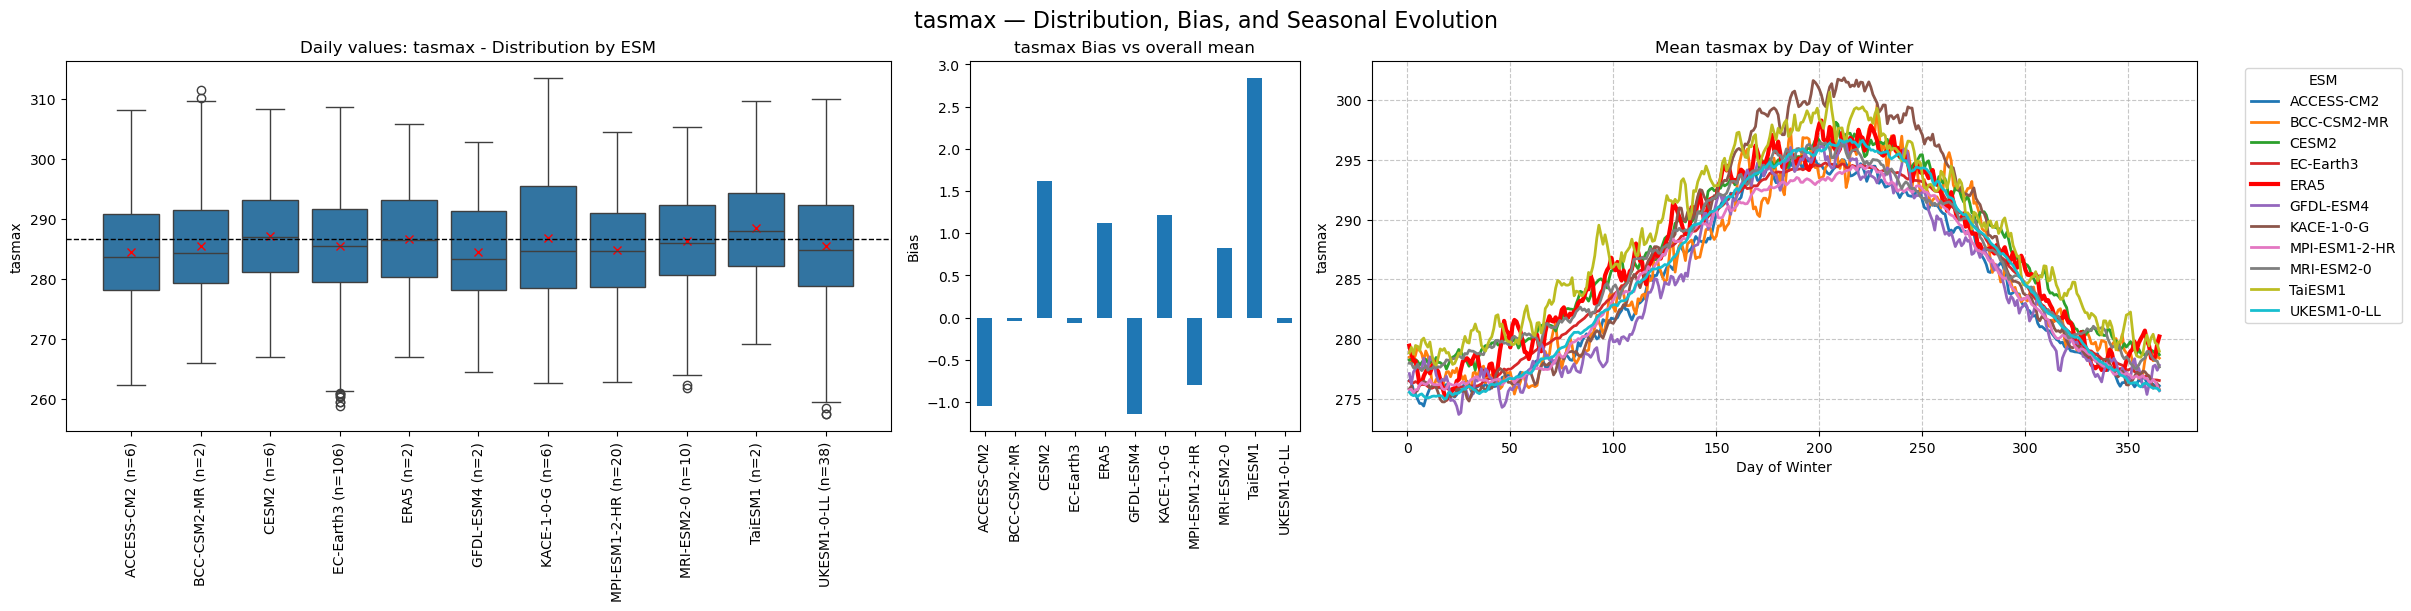

In [ ]:
# Loop over variables and plot boxplot, bias, and seasonal lineplot
for var in variables:
    fig, axes = plt.subplots(
        1, 3,
        figsize=(24, 6),
        gridspec_kw={'width_ratios': [3, 1.2, 3]},
        constrained_layout=True
    )

    # 1. Boxplot (left)
    sns.boxplot(data=df, x='ESM_label', y=var, ax=axes[0])
    means = df.groupby('ESM_label')[var].mean()
    # Add mean as a line
    axes[0].plot(means.index, means.values, color='red', marker='x', linestyle='', label='Mean')
    axes[0].axhline(y=ts_datasets[var].sel(ESM_run='ERA5_hist').mean('time'), color='black', linestyle='--', linewidth=1)

    axes[0].set_title(f'Daily values: {var} - Distribution by ESM')
    axes[0].tick_params(axis='x', rotation=90)
    axes[0].set_xlabel('')
    axes[0].set_ylabel(var)

    # 2. Bias barplot (middle)
    model_mean = ts_datasets[var].groupby('ESM').mean().mean('time')
    overall_mean = ts_datasets[var].mean('time').mean()
    bias = model_mean - overall_mean

    bias.to_series().plot.bar(ax=axes[1])
    axes[1].set_title(f'{var} Bias vs overall mean')
    axes[1].set_ylabel('Bias')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=90)


    # 3. Line plot (right)
    if var in final_df.columns:
        for esm, group in final_df.groupby('ESM'):
            if esm == 'ERA5':
                axes[2].plot(group['doy'], group[var], color='red', linewidth=3, label='ERA5')
            else:
                axes[2].plot(group['doy'], group[var], linewidth=2, label=esm)

        axes[2].set_title(f'Mean {var} by Day of Year')
        axes[2].set_xlabel('Day of Year')
        axes[2].set_ylabel(var)
        axes[2].grid(True, linestyle='--', alpha=0.7)
        axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title='ESM')

    # Title
    plt.suptitle(f'{var} — Distribution, Bias, and Seasonal Evolution', fontsize=16)
    plt.show()